# Logistic regression


We talk about logistic regression because it's important to understand his theorical principle


## Definition
 **Logistic regression** is a supervised  learning algorithm used in classification problems.
 The difference between **Linear regression** and **Logistic regression** are :
  -  Linear regression is used for predicting a continuous values like price of houses, economic indicator,... by using more caracteristics or features
  - Logistic regression predicts if an input is in specific class . For example, we need to know if the message is a spam or not, it's called binary classification

  


# Types
- Binary classification: When we have only two categories or classes, such as Yes/No, 0/1 ...
- Multinomial Logistic regression : when we have three or more unordered classes, such as classifying animals if they are cat, dog, rabbit,...
- Ordinal Logistic regression : when the dependent variable has three or more categories with a natural order, such as Low, Medium, and High.

## Principle
  **Logistic regression** calculate the probability that an input is in certain class and we know that the probability is a function $$P: Ω \to [0,1]$$, where takes the value between 0 and 1

 **Logistic regression** uses the sigmoid function that convert the value of input to probability
 $$f(z)= \frac{1}{1+e^{-z}}$$




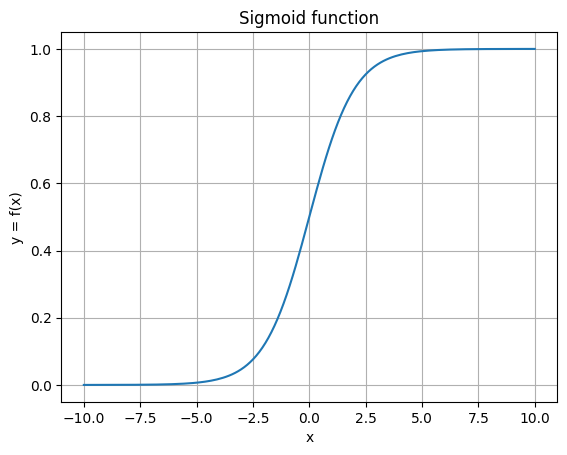

In [23]:
import numpy as np
import matplotlib.pyplot as plt

X = np.linspace(-10,10,150)
y = 1/(1+np.exp(-X))
plt.plot(X,y)
plt.xlabel("x")
plt.ylabel("y = f(x)")
plt.title("Sigmoid function")
plt.grid()


We can see that the values of this sigmoid function is between 0 and 1

The **Logistic regression** works as follows :
Logistic regression model works by implementing the linear equation to predict the class of an object based on independent variables.


Let suppose we have the input features represented as a matrix $X$ and take the case of binary classification

$$
X =
\begin{bmatrix}
x_{11} & \cdots & x_{1m} \\
x_{21} & \cdots & x_{2m} \\
\vdots & \ddots & \vdots \\
x_{n1} & \cdots & x_{nm}
\end{bmatrix}
$$


$$
\text{and} \quad
Y =
\begin{cases}
0 & \text{if Class 1} \\
1 & \text{if Class 2}
\end{cases}
$$
We apply the multi-linear function to the input variables $X$ and we obtain
$$ z = β_1 x_1+....+\beta_n x_n + b$$ $$z = (∑_{i=1}^{n}β_ix_i)+ b$$
$x_i$ is the $i$th observation  of X , $β_i = [β_1,β_2,...,β_n]$ is the coefficient and $b$ is the intercept

We can write
$$ z = β. X + b$$
With $z$ is the continous value from the linear regression( We need to use linear regression function to predict the continous value)

Logistic regression then applies the sigmoid function to $z$ to convert it into a probability between 0 and 1 which can be used to predict the class.


Let's apply the logistic regression with the datasets titanic from kaggle

In [24]:
import pandas as pd
import numpy as np
import os

In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("heptapod/titanic")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic' dataset.
Path to dataset files: /kaggle/input/titanic


In [26]:
name = os.listdir(path)
print(name)

['train_and_test2.csv']


In [27]:
df = pd.read_csv(path+"/train_and_test2.csv")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

We see that all type of variables are numerical. Now, we need to check the number of missing values

In [29]:
df.isnull().sum()

,0
Passengerid,0
Age,0
Fare,0
Sex,0
sibsp,0
zero,0
zero.1,0
zero.2,0
zero.3,0
zero.4,0


In [30]:
print(df.columns)

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')


# Logistic regression

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix



## Feature Selection: selecting relevant features for model training.

In [32]:
cols_to_keep = ['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked', '2urvived']
df_clean = df[cols_to_keep].copy()

In [33]:
df_clean.rename(columns={'2urvived': 'Survived'}, inplace=True)
# We rename the column 2survied -> Survived

## Handling missing values
Fill missing Embarked values with the most frequent category.

In [34]:
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

print("Cleaned Data Preview:")
print(df_clean.head())

Cleaned Data Preview:
    Age     Fare  Sex  sibsp  Parch  Pclass  Embarked  Survived
0  22.0   7.2500    0      1      0       3       2.0         0
1  38.0  71.2833    1      1      0       1       0.0         1
2  26.0   7.9250    1      0      0       3       2.0         1
3  35.0  53.1000    1      1      0       1       2.0         1
4  35.0   8.0500    0      0      0       3       2.0         0


In [35]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1309 non-null   float64
 1   Fare      1309 non-null   float64
 2   Sex       1309 non-null   int64  
 3   sibsp     1309 non-null   int64  
 4   Parch     1309 non-null   int64  
 5   Pclass    1309 non-null   int64  
 6   Embarked  1309 non-null   float64
 7   Survived  1309 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 81.9 KB


In [36]:
print(f"Dtype: {df_clean['Embarked'].dtype}")
print(f"Value Counts:\n{df_clean['Embarked'].value_counts(dropna=False)}")
print(f"Check Type: {type(df_clean['Embarked'].iloc[0])}")

Dtype: float64
Value Counts:
Embarked
2.0    916
0.0    270
1.0    123
Name: count, dtype: int64
Check Type: <class 'numpy.float64'>


## One-Hot Encoding: convert categorical variables into numerical features.

In [37]:
# Sex: female=0, male=1,Embarked: we use One-Hot Encoding
df_clean = pd.get_dummies(df_clean, columns=['Sex', 'Embarked'], drop_first=True)

# We separate X and your target y
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

# Train-Test Split: 80% data for training and 20% for testing the model.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           1309 non-null   float64
 1   Fare          1309 non-null   float64
 2   sibsp         1309 non-null   int64  
 3   Parch         1309 non-null   int64  
 4   Pclass        1309 non-null   int64  
 5   Survived      1309 non-null   int64  
 6   Sex_1         1309 non-null   bool   
 7   Embarked_1.0  1309 non-null   bool   
 8   Embarked_2.0  1309 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 65.3 KB


We use StandardScaler to put all numerical features on a similar scale

In [39]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Build the model

In [40]:
# Initialization and training
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_logistic = logistic_model.predict(X_test_scaled)

## Evaluation

In [41]:
#Logistic regression
accuracy = accuracy_score(y_test, y_pred_logistic)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))



Model Accuracy: 76.72%

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       189
           1       0.64      0.37      0.47        73

    accuracy                           0.77       262
   macro avg       0.72      0.65      0.66       262
weighted avg       0.75      0.77      0.74       262



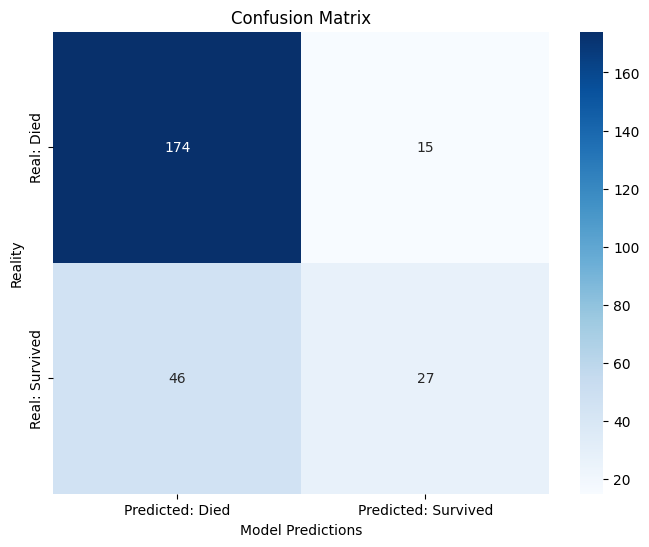

In [42]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic)

# Display this
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Died', 'Predicted: Survived'],
            yticklabels=['Real: Died', 'Real: Survived'])

plt.xlabel('Model Predictions')
plt.ylabel('Reality')
plt.title('Confusion Matrix')
plt.show()

# Random Forest
Random Forest is a machine learning algorithm that uses many decision trees to make better predictions.Each tree is trained on a random subset of the data, and their predictions are combined by majority voting(bagging method).This makes Random Forest an ensemble learning method. This helps in improving accuracy and reducing errors. Effectively, it reduces overfitting

## Build the model

In [43]:
# Initialization and training
model = RandomForestClassifier()
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

Model Accuracy: 69.47%

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       189
           1       0.45      0.44      0.44        73

    accuracy                           0.69       262
   macro avg       0.62      0.62      0.62       262
weighted avg       0.69      0.69      0.69       262



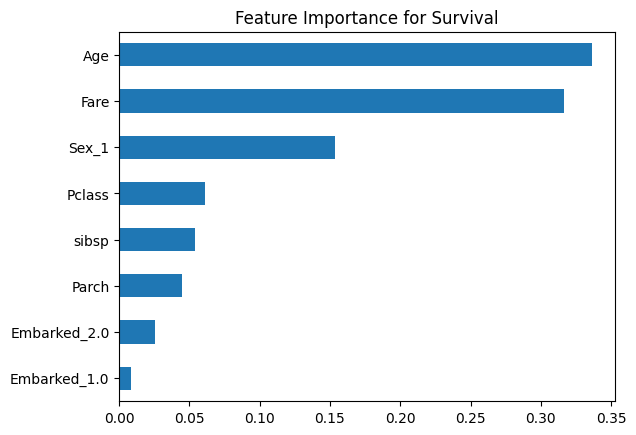

In [44]:
# Random forest
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance for Survival')
plt.show()

## Confusion Matrix

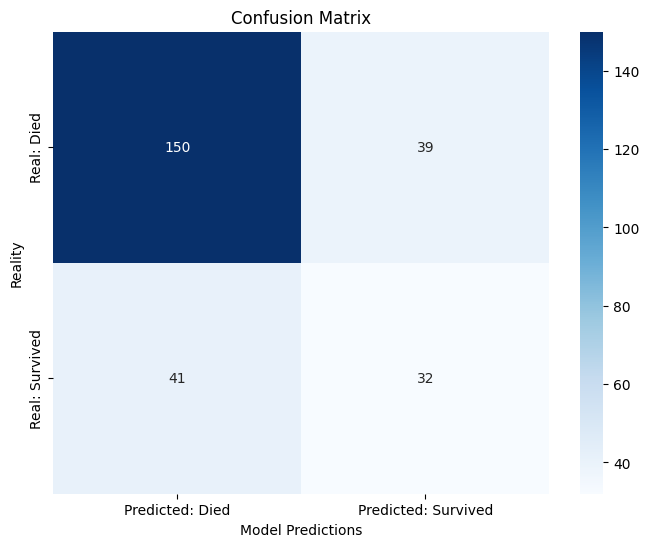

In [45]:
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Died', 'Predicted: Survived'],
            yticklabels=['Real: Died', 'Real: Survived'])

plt.xlabel('Model Predictions')
plt.ylabel('Reality')
plt.title('Confusion Matrix')
plt.show()

In [46]:
# Checking class distribution
print(y_train.value_counts())

Survived
0    778
1    269
Name: count, dtype: int64


The class distribution shows an imbalance between the two classes: 778 passengers died, compared with 269 survivors. Therefore, we use
**class_weight='balanced'** to give more importance to the minority class, i.e. the survivors

# Optimized Random Forest
## Model optimization

In [47]:
# Optimized Random Forest
model_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced', # 'balanced' gives more weight to the minority class (survivors).
    random_state=42
)

# Training
model_balanced.fit(X_train_scaled, y_train)

# New prediction
y_pred_balanced = model_balanced.predict(X_test_scaled)

# Display new results
print("--- Nouveaux résultats (Modèle Équilibré) ---")
print(f"Nouvelle Accuracy: {accuracy_score(y_test, y_pred_balanced) * 100:.2f}%")
print("\nNouveau Rapport de Classification:")
print(classification_report(y_test, y_pred_balanced))

--- Nouveaux résultats (Modèle Équilibré) ---
Nouvelle Accuracy: 70.61%

Nouveau Rapport de Classification:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       189
           1       0.47      0.48      0.48        73

    accuracy                           0.71       262
   macro avg       0.64      0.64      0.64       262
weighted avg       0.71      0.71      0.71       262



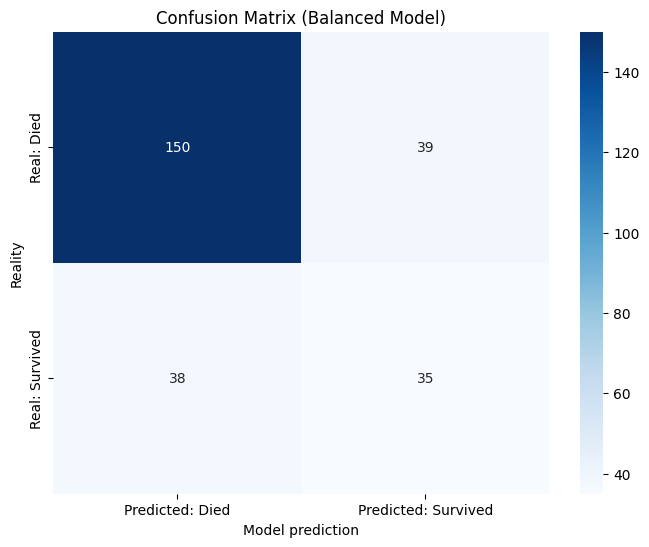

In [48]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_balanced)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Died', 'Predicted: Survived'],
            yticklabels=['Real: Died', 'Real: Survived'])

plt.xlabel('Model prediction')
plt.ylabel('Reality')
plt.title('Confusion Matrix (Balanced Model)')
plt.show()

# Final results

## Interpretation
The comparaison shows for the Class 1:
- Logistic Regression achieves the highest accuracy (76.72%) and the highest precision (0.64) but low Recall with (0.37) and low F1-score with (0.47)
- Optimized Random Forest has (70.61%) accuracy, low precision (0.47) and  recall,F1-score with (0.48)

Therefore, the choice of model depends on the goal. If the goal is generally predictive model so Logistic Regression is the better choice because of its higher accuracy
However, if the priority is to identify as many survivors as possible, the optimized Random Forest is more suitable because it has a higher recall for the survivor class (48% vs. 37%).